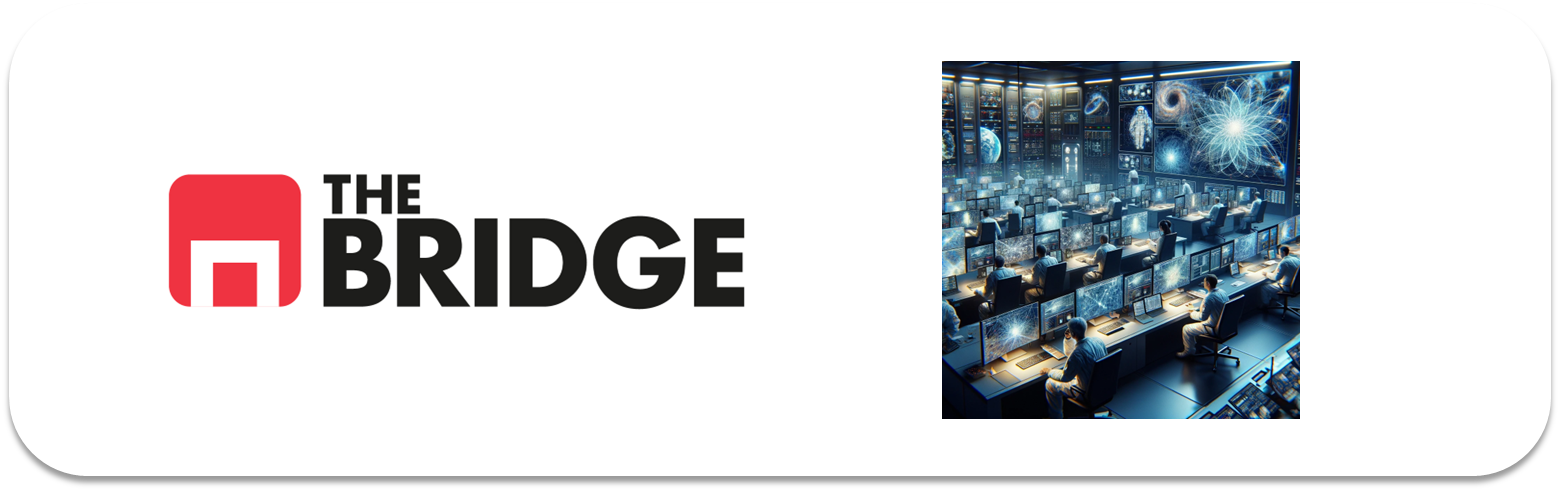

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt
import numpy as np
import os
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
# filter warnings
warnings.filterwarnings('ignore')
from PIL import Image
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



Tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test"

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

Función para leer y redimiensionar imágenes a 32x32

In [2]:
IMG_SIZE = (32, 32)

def load_and_resize_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    return np.array(img) / 255.0

Función para obtener la etiqueta según el nombre del archivo

In [3]:
def get_label_from_filename(filename):
    fname = filename.lower()
    if fname.startswith("cat"):
        return 0   # gato
    elif fname.startswith("dog"):
        return 1   # perro
    else:
        raise ValueError(f"No se reconoce clase en el nombre: {filename}")

Función para cargar todas las imágenes de uno o varios directorios

In [4]:
def load_dataset_from_dirs(dir_list):
    X = []
    y = []
    for d in dir_list:
        for fname in os.listdir(d):
            fpath = os.path.join(d, fname)
            if not os.path.isfile(fpath):
                continue
            try:
                img = load_and_resize_image(fpath)
                label = get_label_from_filename(fname)
                X.append(img)
                y.append(label)
            except Exception as e:
                print(f"Error con {fpath}: {e}")
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

Lo aplicamos a las carpetas de imágenes

In [5]:
train_dirs = [
    "data/github_train_0",
    "data/github_train_1",
    "data/github_train_2",
    "data/github_train_3"
]

test_dirs = ["data/github_test"]

X_train, y_train = load_dataset_from_dirs(train_dirs)
X_test, y_test   = load_dataset_from_dirs(test_dirs)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (4000, 32, 32, 3) y_train: (4000,)
X_test: (1000, 32, 32, 3) y_test: (1000,)


2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

Mini-EDA (visualizar algunas imágenes)

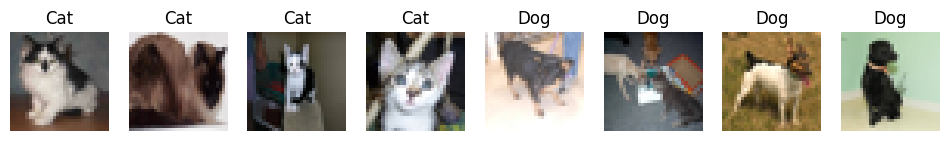

In [6]:
import matplotlib.pyplot as plt
# verificamos que las imágenes están bien cargadas y con sus etiquetas correspondientes

def show_samples(X, y, n=8):
    plt.figure(figsize=(12, 3))
    idxs = np.random.choice(len(X), n)
    for i, idx in enumerate(idxs):
        plt.subplot(1, n, i+1)
        plt.imshow(X[idx])
        plt.title("Cat" if y[idx] == 0 else "Dog")
        plt.axis("off")
    plt.show()

show_samples(X_train, y_train)


In [7]:
# keras necesita X_train como float32
# y_train como enteros. ambas ya están
# hacemos shuffle del dataset
from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

Construcción de modelo CNN con dos bloque Conv y Pool

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    # Bloque 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)), # tamaño pequeño ideal para cnn compactas
    layers.MaxPooling2D((2,2)),

    # Bloque 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Bloque 3 opcional (mejora rendimiento)
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Clasificación
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), #para evitar overfitting
    layers.Dense(1, activation='sigmoid')   # binaria: perro/gato
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [10]:
history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5228 - loss: 0.6913 - val_accuracy: 0.5050 - val_loss: 0.6895
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5794 - loss: 0.6712 - val_accuracy: 0.6550 - val_loss: 0.6339
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6475 - loss: 0.6381 - val_accuracy: 0.6888 - val_loss: 0.5997
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6784 - loss: 0.5980 - val_accuracy: 0.6875 - val_loss: 0.6247
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7075 - loss: 0.5701 - val_accuracy: 0.6938 - val_loss: 0.5849
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7456 - loss: 0.5136 - val_accuracy: 0.7212 - val_loss: 0.5449
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7856 - loss: 0.4687 - val_accuracy: 0.7375 - val_loss: 0.5379
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7962 - loss: 0.4293 - val_accuracy: 0

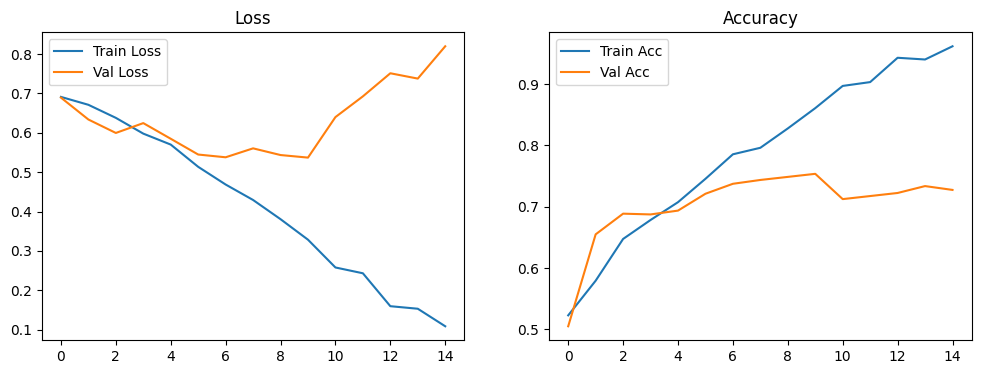

In [11]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss")

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title("Accuracy")

    plt.show()

plot_history(history)

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7760 - loss: 0.5252
Test Loss: 0.5252249240875244
Test Accuracy: 0.7760000228881836


In [13]:
# obtenemos predicciones del modelo
y_pred_prob = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [14]:
# convertimos a clases
y_pred = (y_pred_prob > 0.5).astype("int32")

In [15]:
# reporte de clasificación
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))


              precision    recall  f1-score   support

         Cat       0.75      0.82      0.79       500
         Dog       0.81      0.73      0.76       500

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000



el accuracy es de 78 qué es más bien razonable

matriz de confusión

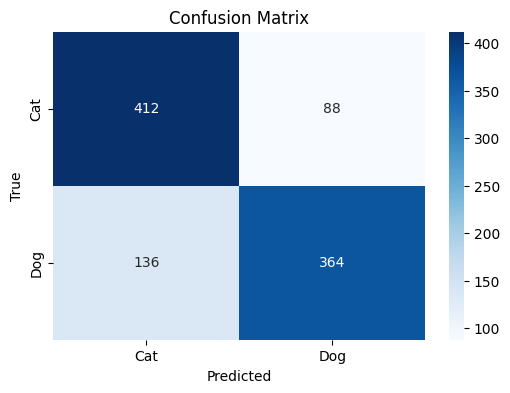

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cat", "Dog"],
            yticklabels=["Cat", "Dog"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


88 perros han sido confundidos con gatos y 136 gatos han sido clasificacdos como perros

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.

In [23]:
print(type(y_test))

<class 'numpy.ndarray'>


In [24]:
# Selección del 10% de imágenes mal clasificadas con mayor confianza en la clase errónea
# primero identificamos los errores de clasificación

errors_idx = np.where(y_pred.flatten() != y_test[0])
# Separamos gatos mal clasificados de perros mal clasificados
# Selección del 10% de imágenes mal clasificadas con mayor confianza en la clase errónea
# primero identificamos los errores de clasificación

errors_idx = np.flatnonzero(y_pred.flatten() != y_test)

# Separamos gatos mal clasificados de perros mal clasificados
cats_wrong = errors_idx[y_test[errors_idx] == 0]   # clase real = gato
dogs_wrong = errors_idx[y_test[errors_idx] == 1]   # clase real = perro

# ordenamos por confianza en la clase errónea
# Para gatos mal clasificados como perros
# El modelo predice “perro” cuando prob > 0.5.
# Así que queremos los gatos con probabilidad más alta de ser perro.
cats_wrong_conf = cats_wrong[np.argsort(y_pred_prob[cats_wrong].flatten())[::-1]]
# Para perros mal clasificados como gatos
# El modelo predice “gato” cuando prob < 0.5.
# Así que queremos los perros con probabilidad más baja de ser perro (es decir, más alta de ser gato).
dogs_wrong_conf = dogs_wrong[np.argsort(y_pred_prob[dogs_wrong].flatten())]



In [25]:
# seleccionamos el 10% de cada grupo
def select_top_10_percent(idx_list):
    n = max(1, int(len(idx_list) * 0.10))
    return idx_list[:n]

cats_selected = select_top_10_percent(cats_wrong_conf)
dogs_selected = select_top_10_percent(dogs_wrong_conf)


In [26]:
X_selected = np.concatenate([X_test[cats_selected], X_test[dogs_selected]])
y_selected = np.concatenate([y_test[cats_selected], y_test[dogs_selected]])

visualización de las ima´genes seleccionadas

In [28]:
import math
import matplotlib.pyplot as plt

def show_selected(X, y, title):
    n = len(X)
    cols = min(n, 6)                 # máximo 6 columnas
    rows = math.ceil(n / cols)       # las filas que hagan falta

    plt.figure(figsize=(3*cols, 3*rows))

    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i])
        plt.title("Cat" if y[i] == 0 else "Dog")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

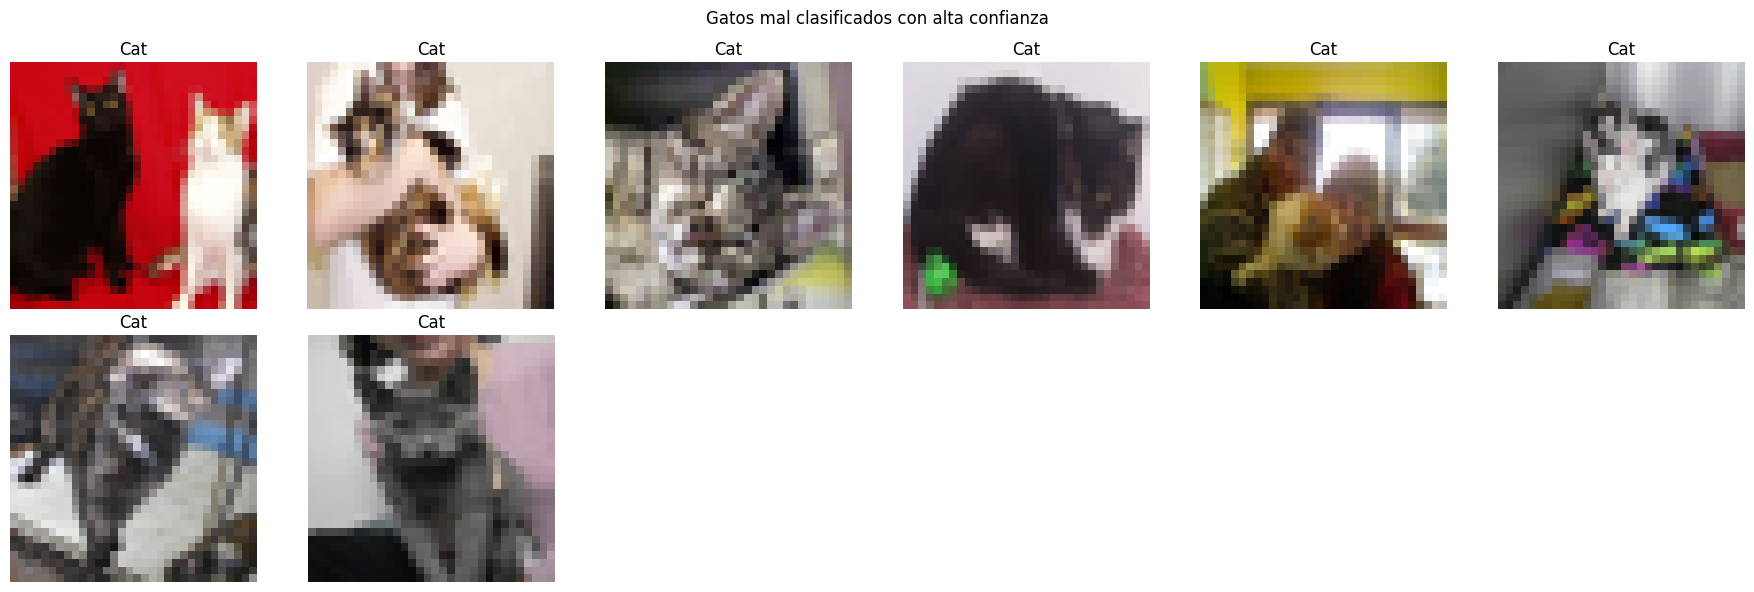

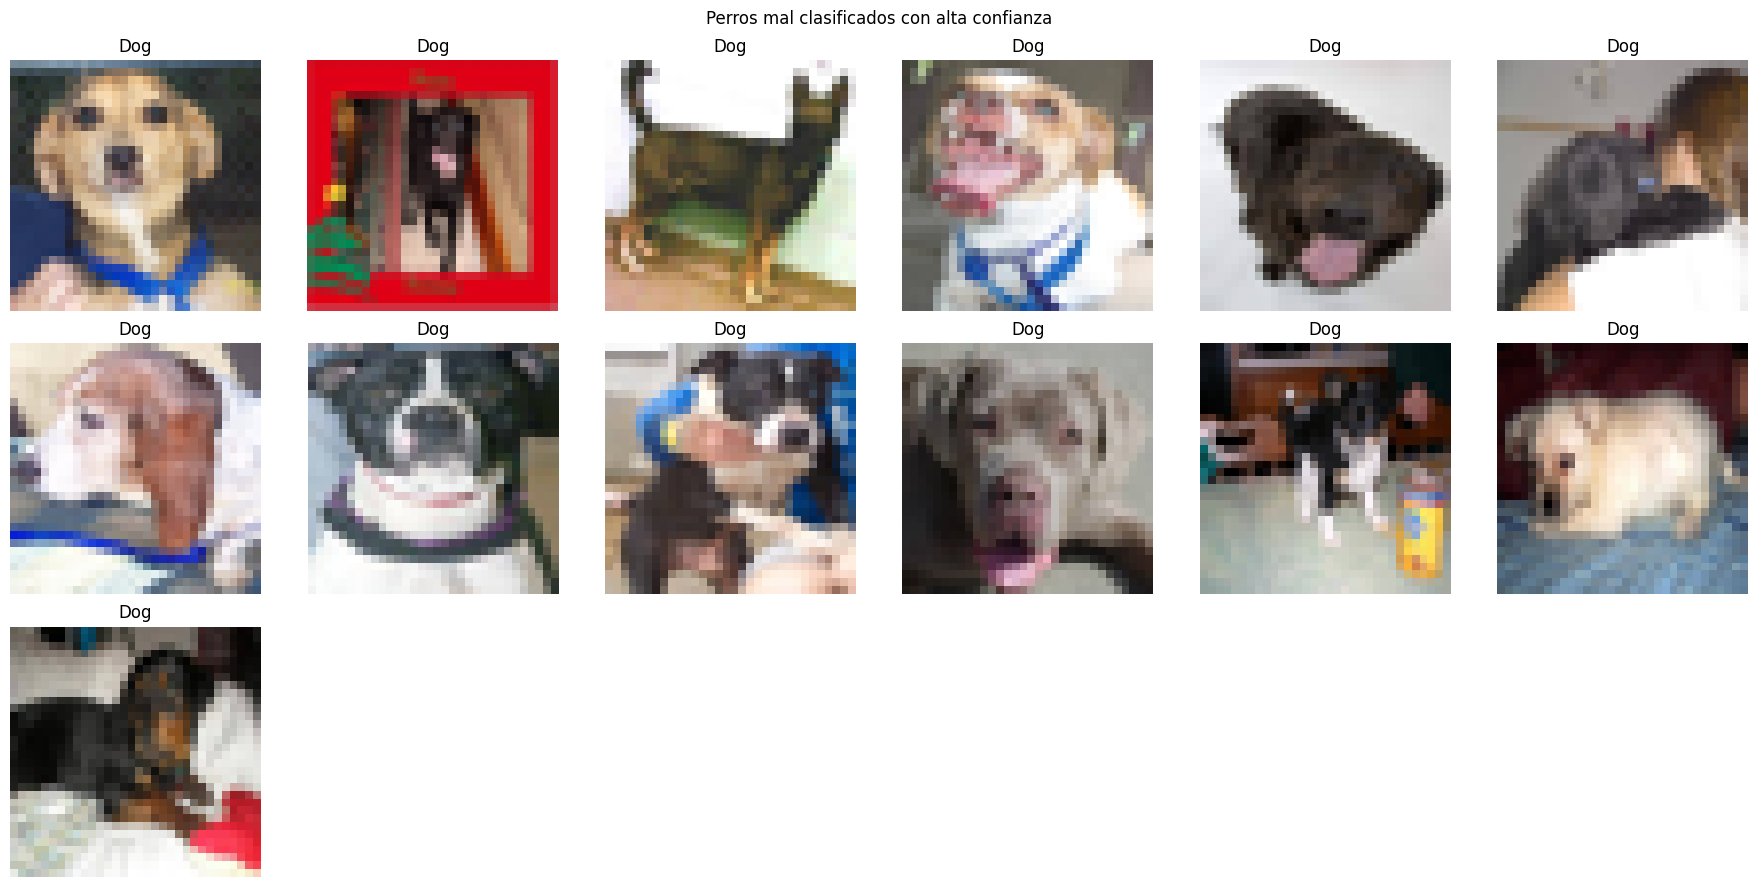

In [29]:
show_selected(X_test[cats_selected], y_test[cats_selected],
              "Gatos mal clasificados con alta confianza")

show_selected(X_test[dogs_selected], y_test[dogs_selected],
              "Perros mal clasificados con alta confianza")